# Training a Small Language Model from Scratch

**CSCI 394 -- Spring 2026 Tutorial**

In tutorials 4 and 5 we *used* pre-trained LLMs. Now we go one level deeper:
we will **build and train a GPT-style language model from scratch** using only
PyTorch. Every component -- tokenizer, architecture, training loop -- is
written from first principles so you can see exactly what is happening.

## What you will build

A **decoder-only Transformer** (~1.5M parameters) trained on the Tiny
Shakespeare dataset. After training it will generate Shakespeare-like text.

## What you will learn

1. Character-level tokenization -- the simplest possible tokenizer
2. How to write a `Dataset` / `DataLoader` for language modeling
3. The full GPT architecture in ~120 lines of PyTorch
4. The language model training loop (cross-entropy next-token prediction)
5. Monitoring training: loss curves and perplexity
6. Autoregressive text generation with temperature
7. How architecture choices (depth, width) affect quality vs compute

## Prerequisites

Only `torch` and `matplotlib`. No Hugging Face, no API keys.

**On Google Colab:** `Runtime > Change runtime type > GPU`  
**On Polaris / Aurora:** `module load conda && conda activate`

> **Inspiration**: This tutorial is inspired by Andrej Karpathy's nanoGPT.
> We have simplified and annotated it for a classroom setting.

---

## Step 0: Setup

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
import time
import math

print(f"PyTorch version: {torch.__version__}")

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Apple MPS")
elif hasattr(torch, "xpu") and torch.xpu.is_available():
    device = torch.device("xpu")
    print("Intel XPU")
else:
    device = torch.device("cpu")
    print("CPU  (training will be slower -- reduce max_iters if needed)")

print(f"Device: {device}")
torch.manual_seed(42)

PyTorch version: 2.10.0
Apple MPS
Device: mps


---

## Step 1: Data -- Tiny Shakespeare

We use the **Tiny Shakespeare** dataset: a concatenation of Shakespeare's plays
(1.1 MB of text, ~1M characters). It is the standard benchmark for small
character-level language models.

Why Shakespeare?
- Small enough to train in minutes
- Rich enough to see meaningful learning (punctuation, word endings, dialogue structure)
- Classic benchmark -- easy to compare results

In [13]:
URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

print("Downloading Tiny Shakespeare...")
urllib.request.urlretrieve(URL, "shakespeare.txt")

with open("shakespeare.txt", "r") as f:
    text = f.read()

print(f"Total characters:  {len(text):,}")
print(f"Unique characters: {len(set(text))}")
print()
print("First 500 characters:")
print("-" * 60)
print(text[:500])

Total characters:  1,115,394
Unique characters: 65

First 500 characters:
------------------------------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


---

## Step 2: Tokenizer -- Character Level

Modern LLMs use sub-word tokenizers (BPE, SentencePiece). For simplicity we
use a **character-level** tokenizer: each unique character is one token.

| Property | Character-level | BPE (GPT-2) |
| -------- | --------------- | ----------- |
| Vocabulary size | ~65 | ~50,000 |
| Sequences per sentence | Long | Short |
| Handles unknown words | Yes (any char) | No |
| Learns word structure | From scratch | Built in |

The trade-off: character models need to learn *everything* (spelling, words,
grammar) from raw character predictions.

In [14]:
# Build vocabulary: all unique characters in the dataset
chars = sorted(set(text))
vocab_size = len(chars)

print(f"Vocabulary ({vocab_size} characters):")
print(repr("".join(chars)))

# Encode: char -> integer
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: "".join(itos[i] for i in ids)

# Verify round-trip
sample = "To be, or not to be"
ids = encode(sample)
print(f"\nEncode '{sample}':")
print(f"  -> {ids}")
print(f"  -> '{decode(ids)}' (decoded back)")

Vocabulary (65 characters):
"\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"

Encode 'To be, or not to be':
  -> [32, 53, 1, 40, 43, 6, 1, 53, 56, 1, 52, 53, 58, 1, 58, 53, 1, 40, 43]
  -> 'To be, or not to be' (decoded back)


---

## Step 3: Dataset and DataLoader

### How language model training works

We slide a window of `block_size` tokens over the text. For each window,
the **input** is positions 0..T-1 and the **target** is positions 1..T
(each token predicts the next one).

```
text:    T  h  e     c  a  t  ...
input:   T  h  e     c  a
target:  h  e     c  a  t
```

The loss is cross-entropy averaged over all positions. This is the
**causal language modeling** objective.

In [4]:
# Encode the full text once
data = torch.tensor(encode(text), dtype=torch.long)
print(f"Data tensor shape: {data.shape}")

# 90% train / 10% validation split
n = int(0.9 * len(data))
train_data = data[:n]
val_data   = data[n:]
print(f"Train: {len(train_data):,} tokens")
print(f"Val:   {len(val_data):,} tokens")


class ShakespeareDataset(Dataset):
    """Sliding-window next-token prediction dataset."""

    def __init__(self, data, block_size):
        self.data = data
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        chunk = self.data[idx : idx + self.block_size + 1]
        x = chunk[:-1]   # input:  tokens 0 .. T-1
        y = chunk[1:]    # target: tokens 1 .. T
        return x, y


# Hyperparameters
block_size = 128    # context window length (tokens)
batch_size = 64

train_dataset = ShakespeareDataset(train_data, block_size)
val_dataset   = ShakespeareDataset(val_data,   block_size)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=0, pin_memory=(device.type == "cuda"))
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          num_workers=0)

# Inspect one batch
xb, yb = next(iter(train_loader))
print(f"\nBatch shape -- x: {xb.shape}, y: {yb.shape}")
print(f"First 10 input tokens:  {xb[0, :10].tolist()}")
print(f"First 10 target tokens: {yb[0, :10].tolist()}")
print(f"Decoded input:  {repr(decode(xb[0, :30].tolist()))}")
print(f"Decoded target: {repr(decode(yb[0, :30].tolist()))}")

Data tensor shape: torch.Size([1115394])
Train: 1,003,854 tokens
Val:   111,540 tokens

Batch shape -- x: torch.Size([64, 128]), y: torch.Size([64, 128])
First 10 input tokens:  [52, 43, 57, 57, 2, 1, 57, 43, 56, 47]
First 10 target tokens: [43, 57, 57, 2, 1, 57, 43, 56, 47, 53]
Decoded input:  'ness! serious vanity!\nMis-shap'
Decoded target: 'ess! serious vanity!\nMis-shape'


---

## Step 4: The Model -- GPT from Scratch

We implement the three building blocks of a GPT-style model:

### 4a. Causal Self-Attention Head
### 4b. Multi-Head Attention
### 4c. Transformer Block (attention + FFN + residuals)
### 4d. GPT (embedding + N blocks + output head)

The architecture matches the diagram in `LLM.md` exactly.

In [5]:
# ── 4a. Single causal self-attention head ─────────────────────────────────
class CausalSelfAttentionHead(nn.Module):
    """One head of causal (masked) self-attention."""

    def __init__(self, n_embd, head_size, block_size, dropout):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        # causal mask: lower-triangular matrix stored as a buffer (not a parameter)
        self.register_buffer("tril",
            torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape          # batch, sequence length, embedding dim
        k = self.key(x)            # (B, T, head_size)
        q = self.query(x)          # (B, T, head_size)
        v = self.value(x)          # (B, T, head_size)

        # scaled dot-product attention
        scale = k.shape[-1] ** -0.5
        attn = q @ k.transpose(-2, -1) * scale   # (B, T, T)

        # apply causal mask: future positions get -inf so softmax -> 0
        attn = attn.masked_fill(self.tril[:T, :T] == 0, float("-inf"))
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)

        return attn @ v            # (B, T, head_size)


# ── 4b. Multi-head attention ───────────────────────────────────────────────
class MultiHeadAttention(nn.Module):
    """n_head independent attention heads concatenated and projected."""

    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        head_size = n_embd // n_head
        self.heads = nn.ModuleList([
            CausalSelfAttentionHead(n_embd, head_size, block_size, dropout)
            for _ in range(n_head)
        ])
        self.proj    = nn.Linear(n_embd, n_embd)   # output projection
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # run all heads in parallel, concatenate along last dimension
        out = torch.cat([h(x) for h in self.heads], dim=-1)  # (B, T, n_embd)
        return self.dropout(self.proj(out))


# ── 4c. Feed-Forward Network (FFN) ────────────────────────────────────────
class FeedForward(nn.Module):
    """Position-wise FFN: Linear -> GeLU -> Linear."""

    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),  # expand to 4x
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),  # project back
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


# ── 4d. Transformer Block ─────────────────────────────────────────────────
class TransformerBlock(nn.Module):
    """One decoder block: LayerNorm -> MHA -> residual, LayerNorm -> FFN -> residual."""

    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = MultiHeadAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ffn  = FeedForward(n_embd, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))   # residual connection around attention
        x = x + self.ffn(self.ln2(x))    # residual connection around FFN
        return x


# ── 4e. Full GPT model ────────────────────────────────────────────────────
class GPT(nn.Module):
    """Decoder-only Transformer language model."""

    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size, dropout):
        super().__init__()
        self.block_size = block_size

        self.tok_emb = nn.Embedding(vocab_size, n_embd)        # token embeddings
        self.pos_emb = nn.Embedding(block_size, n_embd)        # positional embeddings
        self.drop    = nn.Dropout(dropout)

        self.blocks = nn.Sequential(*[
            TransformerBlock(n_embd, n_head, block_size, dropout)
            for _ in range(n_layer)
        ])

        self.ln_f  = nn.LayerNorm(n_embd)                      # final layer norm
        self.head  = nn.Linear(n_embd, vocab_size, bias=False)  # output logits

        # weight tying: token embedding and output head share weights
        self.head.weight = self.tok_emb.weight

        self._init_weights()

    def _init_weights(self):
        """GPT-2 style weight initialisation."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.block_size, "Sequence longer than context window"

        # token + positional embeddings
        tok = self.tok_emb(idx)                              # (B, T, n_embd)
        pos = self.pos_emb(torch.arange(T, device=idx.device))  # (T, n_embd)
        x   = self.drop(tok + pos)                          # (B, T, n_embd)

        # transformer blocks
        x = self.blocks(x)    # (B, T, n_embd)
        x = self.ln_f(x)      # (B, T, n_embd)

        logits = self.head(x) # (B, T, vocab_size)

        if targets is None:
            return logits, None

        # cross-entropy loss: predict next token at every position
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)),
                               targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """Autoregressively generate tokens starting from context `idx`."""
        self.eval()
        for _ in range(max_new_tokens):
            # crop context to block_size
            idx_ctx = idx[:, -self.block_size:]
            logits, _ = self(idx_ctx)
            # take logits at the last position only
            logits = logits[:, -1, :] / temperature   # (B, vocab_size)

            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float("-inf")

            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)  # (B, 1)
            idx = torch.cat([idx, idx_next], dim=1)             # (B, T+1)
        return idx

In [6]:
# ── Model configuration ────────────────────────────────────────────────────
# Adjust these to trade off training speed vs. model quality:
#
#  Fast (CPU, ~2 min):    n_embd=64,  n_head=4, n_layer=4
#  Medium (GPU, ~3 min):  n_embd=128, n_head=4, n_layer=4   <-- default
#  Larger (GPU, ~10 min): n_embd=256, n_head=8, n_layer=6

n_embd   = 128   # embedding dimension
n_head   = 4     # number of attention heads  (head_size = n_embd // n_head = 32)
n_layer  = 4     # number of transformer blocks
dropout  = 0.1

model = GPT(
    vocab_size=vocab_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    block_size=block_size,
    dropout=dropout,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}  ({n_params/1e6:.2f}M)")
print()
print("Layer breakdown:")
for name, p in model.named_parameters():
    print(f"  {name:45s}  {str(list(p.shape)):>20s}  {p.numel():>10,}")

Model parameters: 816,512  (0.82M)

Layer breakdown:
  tok_emb.weight                                            [65, 128]       8,320
  pos_emb.weight                                           [128, 128]      16,384
  blocks.0.ln1.weight                                           [128]         128
  blocks.0.ln1.bias                                             [128]         128
  blocks.0.attn.heads.0.key.weight                          [32, 128]       4,096
  blocks.0.attn.heads.0.query.weight                        [32, 128]       4,096
  blocks.0.attn.heads.0.value.weight                        [32, 128]       4,096
  blocks.0.attn.heads.1.key.weight                          [32, 128]       4,096
  blocks.0.attn.heads.1.query.weight                        [32, 128]       4,096
  blocks.0.attn.heads.1.value.weight                        [32, 128]       4,096
  blocks.0.attn.heads.2.key.weight                          [32, 128]       4,096
  blocks.0.attn.heads.2.query.weight         

In [ ]:
# Quick sanity check: untrained model output
xb_test = xb[:4].to(device)
yb_test = yb[:4].to(device)
logits, loss = model(xb_test, yb_test)
print(f"Logits shape: {logits.shape}")
print(f"Initial loss: {loss.item():.4f}")
print(f"Expected loss (random):  {math.log(vocab_size):.4f}")
print(f"  (cross-entropy of a uniform distribution over {vocab_size} classes)")

# Generate some text before training (should be random garbage)
start = torch.zeros(1, 1, dtype=torch.long, device=device)  # start token = 0
out = model.generate(start, max_new_tokens=100, temperature=1.0)
print("\nGenerated text BEFORE training (random):")
print(repr(decode(out[0].tolist())))

# Keep one fixed prompt so we can compare before vs after training
comparison_prompt = "To be, or not to be"
comparison_new_tokens = 120
comparison_ctx = torch.tensor(encode(comparison_prompt), dtype=torch.long,
                              device=device).unsqueeze(0)
pretrain_prompt_sample = decode(
    model.generate(comparison_ctx, max_new_tokens=comparison_new_tokens,
                   temperature=0.8, top_k=40)[0].tolist()
)
print("\nFixed prompt BEFORE training:")
print(pretrain_prompt_sample)

---

## Step 5: Training

### The training loop

Each iteration:
1. Sample a batch of (input, target) token sequences
2. Forward pass: compute logits and cross-entropy loss
3. Backward pass: compute gradients via backpropagation
4. Clip gradients (prevents exploding gradients)
5. Optimizer step: update weights

We use **AdamW** (Adam with decoupled weight decay) and a **cosine learning
rate schedule** with warmup -- both are standard for LLM training.

### Perplexity

Loss is reported in **nats** (natural log). **Perplexity** = exp(loss) is
more interpretable: it is the "effective vocabulary size" the model is
confused about. Perplexity = 65 means the model has no idea; perplexity = 4
means it is nearly certain which of 4 choices comes next.

In [7]:
# ── Optimiser and LR schedule ──────────────────────────────────────────────
max_iters   = 5000    # total training iterations (reduce to 2000 if on CPU)
warmup_iters = 200    # linear warmup steps
lr_max      = 3e-4
lr_min      = 1e-5
weight_decay = 0.01
grad_clip   = 1.0
eval_interval = 200   # evaluate on validation set every N iterations

optimizer = torch.optim.AdamW(model.parameters(), lr=lr_max,
                               weight_decay=weight_decay, betas=(0.9, 0.95))


def get_lr(step):
    """Cosine decay with linear warmup."""
    if step < warmup_iters:
        return lr_max * step / warmup_iters
    if step > max_iters:
        return lr_min
    decay = (step - warmup_iters) / (max_iters - warmup_iters)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay))
    return lr_min + coeff * (lr_max - lr_min)


@torch.no_grad()
def estimate_loss(n_batches=20):
    """Evaluate train and val loss over n_batches."""
    model.eval()
    out = {}
    for split, loader in [("train", train_loader), ("val", val_loader)]:
        losses = []
        for i, (xb, yb) in enumerate(loader):
            if i >= n_batches:
                break
            xb, yb = xb.to(device), yb.to(device)
            _, loss = model(xb, yb)
            losses.append(loss.item())
        out[split] = np.mean(losses)
    model.train()
    return out


# ── Training loop ─────────────────────────────────────────────────────────
train_losses, val_losses, lrs, iters_logged = [], [], [], []

model.train()
data_iter = iter(train_loader)
t_start = time.time()

print(f"{'Iter':>6s}  {'LR':>9s}  {'Train loss':>11s}  {'Val loss':>10s}  "
      f"{'Val PPL':>8s}  {'Elapsed':>8s}")
print("-" * 68)

for step in range(max_iters + 1):
    # evaluate periodically
    if step % eval_interval == 0:
        losses = estimate_loss()
        train_losses.append(losses["train"])
        val_losses.append(losses["val"])
        iters_logged.append(step)
        elapsed = time.time() - t_start
        lr_now = get_lr(step)
        lrs.append(lr_now)
        print(f"{step:>6d}  {lr_now:>9.2e}  {losses['train']:>11.4f}  "
              f"{losses['val']:>10.4f}  {math.exp(losses['val']):>8.1f}  "
              f"{elapsed:>7.1f}s")

    if step == max_iters:
        break

    # get next batch (cycle through the loader)
    try:
        xb, yb = next(data_iter)
    except StopIteration:
        data_iter = iter(train_loader)
        xb, yb = next(data_iter)

    xb, yb = xb.to(device), yb.to(device)

    # update learning rate
    lr = get_lr(step)
    for pg in optimizer.param_groups:
        pg["lr"] = lr

    # forward + backward + update
    optimizer.zero_grad()
    _, loss = model(xb, yb)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    optimizer.step()

print(f"\nTraining complete in {time.time()-t_start:.1f}s")

  Iter         LR   Train loss    Val loss   Val PPL   Elapsed
--------------------------------------------------------------------
     0   0.00e+00       4.2204      4.2340      69.0      1.1s
   200   3.00e-04       2.5750      2.6031      13.5     12.9s
   400   2.99e-04       2.3925      2.4345      11.4     23.9s
   600   2.95e-04       2.2662      2.3338      10.3     35.2s
   800   2.89e-04       2.1333      2.2055       9.1     46.2s
  1000   2.81e-04       2.0178      2.0938       8.1     57.3s
  1200   2.70e-04       1.9253      2.0301       7.6     68.4s
  1400   2.58e-04       1.8483      1.9708       7.2     79.5s
  1600   2.43e-04       1.7925      1.9280       6.9     90.5s
  1800   2.27e-04       1.7436      1.8702       6.5    101.6s
  2000   2.10e-04       1.7075      1.8497       6.4    112.6s
  2200   1.93e-04       1.6575      1.7923       6.0    123.8s
  2400   1.74e-04       1.6377      1.7772       5.9    134.8s
  2600   1.55e-04       1.6220      1.7043       

---

## Step 6: Loss Curves and Analysis

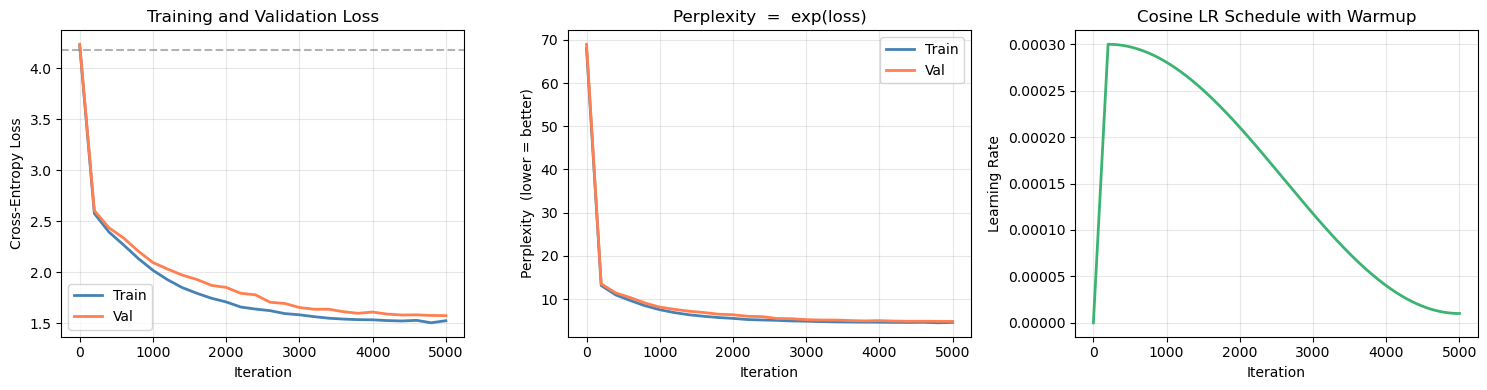

Final val loss: 1.5734
Final val perplexity: 4.8
(started at perplexity 65 = random, now ~5)


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curves
ax = axes[0]
ax.plot(iters_logged, train_losses, label="Train", color="steelblue", lw=2)
ax.plot(iters_logged, val_losses,   label="Val",   color="coral",     lw=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
ax.grid(alpha=0.3)
ax.axhline(math.log(vocab_size), color="gray", ls="--", alpha=0.6,
           label="random baseline")

# Perplexity
ax = axes[1]
ax.plot(iters_logged, [math.exp(l) for l in train_losses], label="Train",
        color="steelblue", lw=2)
ax.plot(iters_logged, [math.exp(l) for l in val_losses],   label="Val",
        color="coral",     lw=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("Perplexity  (lower = better)")
ax.set_title("Perplexity  =  exp(loss)")
ax.legend()
ax.grid(alpha=0.3)

# LR schedule
ax = axes[2]
lr_curve = [get_lr(i) for i in range(max_iters + 1)]
ax.plot(range(max_iters + 1), lr_curve, color="mediumseagreen", lw=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("Learning Rate")
ax.set_title("Cosine LR Schedule with Warmup")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/llm_training_curves.svg", bbox_inches="tight")
plt.show()

final_val_loss = val_losses[-1]
print(f"Final val loss: {final_val_loss:.4f}")
print(f"Final val perplexity: {math.exp(final_val_loss):.1f}")
print(f"(started at perplexity {vocab_size} = random, now ~{math.exp(final_val_loss):.0f})")

---

## Step 7: Text Generation

We now use the trained model to generate Shakespeare-like text.
Recall: the model generates one token at a time, each conditioned on all
previous tokens (autoregressive decoding).

### Temperature

Temperature `T` scales the logits before softmax:
- `T < 1`: sharper distribution → more repetitive, predictable text
- `T = 1`: raw model distribution
- `T > 1`: flatter distribution → more random, creative text

In [9]:
def sample(prompt="", max_new_tokens=300, temperature=0.8, top_k=40):
    """Generate text from an optional prompt string."""
    if prompt:
        ctx = torch.tensor(encode(prompt), dtype=torch.long,
                           device=device).unsqueeze(0)
    else:
        ctx = torch.zeros(1, 1, dtype=torch.long, device=device)
    out = model.generate(ctx, max_new_tokens=max_new_tokens,
                         temperature=temperature, top_k=top_k)
    return decode(out[0].tolist())


# Compare temperatures
for temp in [0.5, 0.8, 1.2]:
    print(f"\n{'='*60}")
    print(f"Temperature = {temp}")
    print('='*60)
    print(sample(prompt="KING:", max_new_tokens=200, temperature=temp))


Temperature = 0.5
KING:
The name be the comforth, I may for the shall be to did uncle
The say the shall excerting are the shall not be charge;
The fear for heart and the have to the god of the duke of her death.

DUKE VINCE

Temperature = 0.8
KING:
The were prayes partion, I think my heart,
Besite uncless to mean's the worlds cannot you,
Your son, for for that be her beseechs.

QUEEN MARGARET:
O, go my a their as been more gentleman,
That first

Temperature = 1.2
KING:
Corthe having more
Flolder to lord els; pries all por in rote?

QUEEN ELIZABETH:
Come bed Here can the commeter spinle, this laves
sufforke that beforg the sand mays
What of think onceive the well.' 


In [ ]:
# Compare the same prompt before vs after training
posttrain_prompt_sample = sample(
    prompt=comparison_prompt,
    max_new_tokens=comparison_new_tokens,
    temperature=0.8,
    top_k=40,
)

print(f"Prompt: {comparison_prompt}")
print("\nBEFORE training:")
print(pretrain_prompt_sample)
print("\nAFTER training:")
print(posttrain_prompt_sample)

---

## Step 8: Inspecting What the Model Learned

Let us visualise the **attention weights** of the trained model on a
short prompt to see which tokens attend to which.

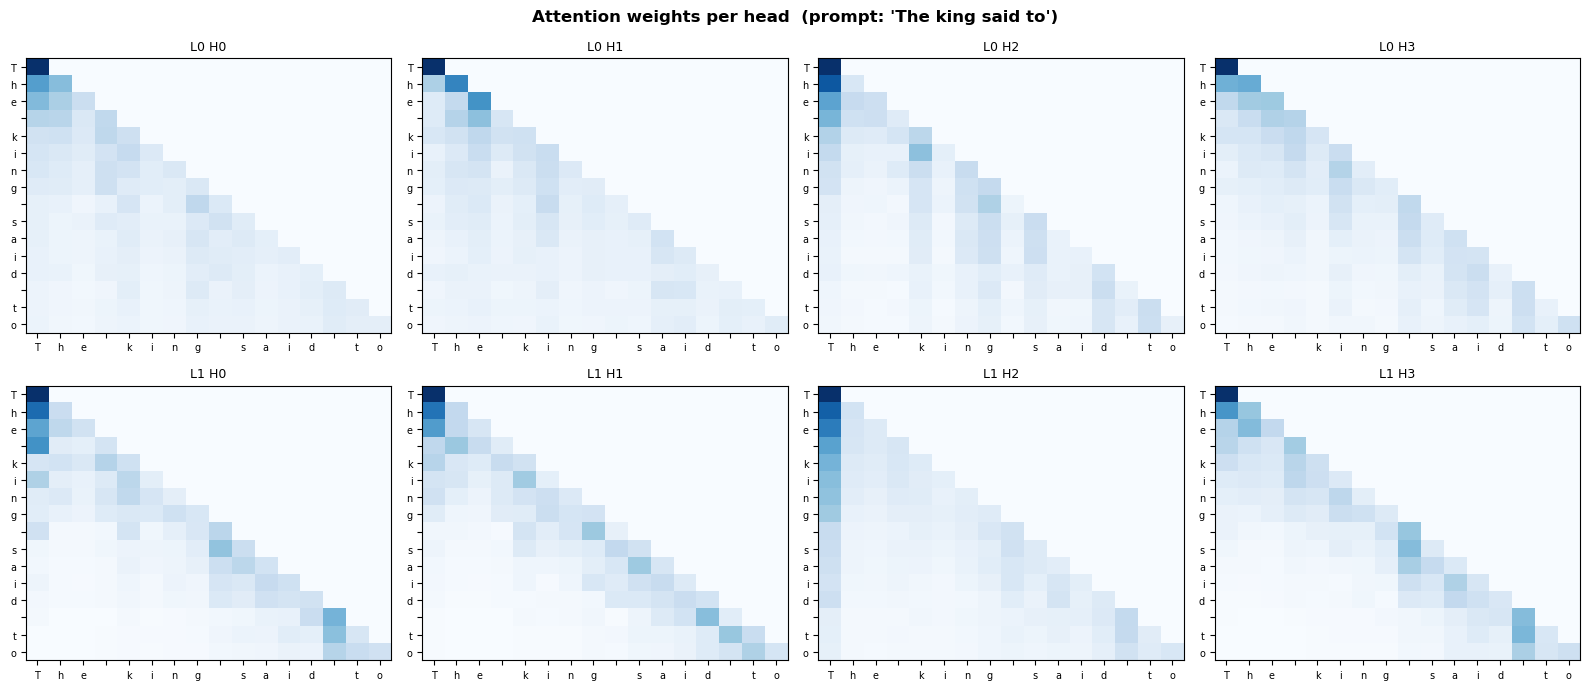

Each row = query token. Each column = key token attended to.
Upper triangle is 0 (causal mask). Different heads learn different patterns.


In [10]:
def get_attention_weights(prompt, layer=0, head=0):
    """Extract attention weights from a specific layer and head."""
    model.eval()
    tokens = encode(prompt)
    x = torch.tensor(tokens, dtype=torch.long, device=device).unsqueeze(0)
    T = len(tokens)

    # run the embedding
    tok = model.tok_emb(x)
    pos = model.pos_emb(torch.arange(T, device=device))
    h = model.drop(tok + pos)

    # run blocks up to the target layer
    for i, block in enumerate(model.blocks):
        if i == layer:
            # intercept attention weights from this block
            attn_module = block.attn.heads[head]
            normed = block.ln1(h)
            k = attn_module.key(normed)
            q = attn_module.query(normed)
            scale = k.shape[-1] ** -0.5
            scores = q @ k.transpose(-2, -1) * scale  # (1, T, T)
            scores = scores.masked_fill(
                attn_module.tril[:T, :T] == 0, float("-inf"))
            weights = F.softmax(scores, dim=-1)       # (1, T, T)
            return weights[0].detach().cpu().numpy(), [c for c in prompt]
        h = block(h)
    return None, None


prompt = "The king said to"
chars_in_prompt = list(prompt)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle(f"Attention weights per head  (prompt: '{prompt}')",
             fontsize=12, fontweight="bold")

for layer in range(min(2, n_layer)):
    for head in range(n_head):
        ax = axes[layer][head]
        weights, chars = get_attention_weights(prompt, layer=layer, head=head)
        im = ax.imshow(weights, cmap="Blues", vmin=0, vmax=1, aspect="auto")
        ax.set_title(f"L{layer} H{head}", fontsize=9)
        ax.set_xticks(range(len(chars)))
        ax.set_yticks(range(len(chars)))
        ax.set_xticklabels(chars_in_prompt, fontsize=7)
        ax.set_yticklabels(chars_in_prompt, fontsize=7)

plt.tight_layout()
plt.show()
print("Each row = query token. Each column = key token attended to.")
print("Upper triangle is 0 (causal mask). Different heads learn different patterns.")

---

## Step 9: Architecture Ablations

How much does each design choice matter?
Run this cell to train three variants and compare their final validation loss.

In [11]:
def train_variant(name, n_embd, n_head, n_layer, n_iters=1000):
    """Train a model variant and return its final val loss."""
    m = GPT(vocab_size=vocab_size, n_embd=n_embd, n_head=n_head,
            n_layer=n_layer, block_size=block_size, dropout=dropout).to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=3e-4, weight_decay=0.01)
    m.train()
    it = iter(train_loader)
    for step in range(n_iters):
        try:
            xb, yb = next(it)
        except StopIteration:
            it = iter(train_loader)
            xb, yb = next(it)
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        _, loss = m(xb, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()

    # evaluate
    m.eval()
    losses = []
    for i, (xb, yb) in enumerate(val_loader):
        if i >= 20: break
        with torch.no_grad():
            _, loss = m(xb.to(device), yb.to(device))
        losses.append(loss.item())
    val_loss = np.mean(losses)
    params = sum(p.numel() for p in m.parameters())
    print(f"  {name:<30s}  params={params/1e6:.2f}M  val_loss={val_loss:.4f}  "
          f"ppl={math.exp(val_loss):.1f}")
    return val_loss, params


print("Architecture ablation (1000 iters each):")
print("-" * 70)
results = []
variants = [
    ("Tiny  (64d, 2h, 2L)",   64,  2, 2),
    ("Small (128d, 4h, 4L)",  128, 4, 4),
    ("Medium (256d, 8h, 6L)", 256, 8, 6),
    ("Wide only (256d, 4h, 2L)", 256, 4, 2),
    ("Deep only (64d, 4h, 8L)",   64, 4, 8),
]
for v in variants:
    vl, np_ = train_variant(*v)
    results.append((v[0], vl, np_))

Architecture ablation (1000 iters each):
----------------------------------------------------------------------
  Tiny  (64d, 2h, 2L)             params=0.11M  val_loss=2.4364  ppl=11.4
  Small (128d, 4h, 4L)            params=0.82M  val_loss=2.0044  ppl=7.4
  Medium (256d, 8h, 6L)           params=4.78M  val_loss=1.5926  ppl=4.9
  Wide only (256d, 4h, 2L)        params=1.63M  val_loss=1.5899  ppl=4.9
  Deep only (64d, 4h, 8L)         params=0.41M  val_loss=2.2619  ppl=9.6


In [ ]:
# Plot ablation results
names    = [r[0] for r in results]
val_lss  = [r[1] for r in results]
n_params = [r[2] / 1e6 for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

colors = plt.cm.tab10(np.linspace(0, 0.5, len(names)))
ax1.barh(names, val_lss, color=colors, edgecolor="black")
ax1.set_xlabel("Val Loss (lower = better)")
ax1.set_title("Architecture Ablation: Val Loss")
ax1.grid(axis="x", alpha=0.3)

ax2.scatter(n_params, val_lss, c=colors, s=120, edgecolors="black", zorder=3)
for i, name in enumerate(names):
    ax2.annotate(name.split("(")[0].strip(), (n_params[i], val_lss[i]),
                 fontsize=8, xytext=(5, 3), textcoords="offset points")
ax2.set_xlabel("Parameters (M)")
ax2.set_ylabel("Val Loss")
ax2.set_title("Val Loss vs Model Size")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("Key insight: more parameters generally helps, but architecture shape matters too.")

---

## Step 10: Save and Reload the Model

In [ ]:
# Save
checkpoint = {
    "model_state": model.state_dict(),
    "config": dict(vocab_size=vocab_size, n_embd=n_embd, n_head=n_head,
                   n_layer=n_layer, block_size=block_size, dropout=dropout),
    "stoi": stoi,
    "itos": itos,
    "val_loss": val_losses[-1],
}
torch.save(checkpoint, "shakespeare_gpt.pt")
print("Model saved to shakespeare_gpt.pt")

# Reload
ckpt = torch.load("shakespeare_gpt.pt", map_location=device)
cfg  = ckpt["config"]
model2 = GPT(**cfg).to(device)
model2.load_state_dict(ckpt["model_state"])
print(f"Model reloaded.  Val loss was {ckpt['val_loss']:.4f}")

# Quick generation check
model2.eval()
ctx = torch.tensor(encode("HAMLET:"), dtype=torch.long, device=device).unsqueeze(0)
out = model2.generate(ctx, max_new_tokens=100, temperature=0.8)
print(decode(out[0].tolist()))

---

## Summary

| Component | What we built | Key idea |
| --------- | ------------- | -------- |
| **Tokenizer** | Character-level (65 tokens) | Maps chars ↔ integers |
| **Dataset** | Sliding-window next-token prediction | Input[0:T-1] predicts Target[1:T] |
| **Attention head** | Scaled dot-product with causal mask | Future tokens set to -∞ |
| **Multi-head** | n_head independent heads concatenated | Different relationship types |
| **FFN** | Linear → GeLU → Linear (4× expand) | Non-linear feature mixing |
| **Block** | Pre-norm + attention + FFN + residuals | Gradient highway |
| **GPT** | Embedding + N blocks + LM head | End-to-end language model |
| **Training** | AdamW + cosine LR + grad clip | Standard LLM recipe |
| **Generation** | Autoregressive + temperature + top-k | Control randomness |

### Connections to HPC

- **Memory**: even this tiny model (1.5M params) uses ~6 MB at FP32. GPT-3 = 700 GB.
- **Compute**: `O(T²)` attention per layer -- doubled context = 4× attention cost.
- **Data parallelism**: split the batch across GPUs; each sees the same model.
- **Mixed precision**: use `torch.autocast` for 2× speedup with almost no accuracy loss.

### Experiments to try

1. Train on a different text (your own dataset, code, poems)
2. Replace character tokenization with a BPE tokenizer (`tiktoken`)
3. Add `torch.autocast` (FP16/BF16) and measure the speedup
4. Implement Flash Attention using `F.scaled_dot_product_attention`
5. Train on multiple GPUs using `DistributedDataParallel` (see Tutorial 6)